### Code Applications
---

### 1) Contour plots

In [72]:
# Libraries
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# import matplotlib as mpl
# mpl.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# import warnings
# warnings.simplefilter(action='ignore', category=FutureWarning)

In [73]:
# here we generate many equally spaced points
x1 = np.linspace(-10.0, 10.0, 201)
x2 = np.linspace(-10.0, 10.0, 201)

In [74]:
# here we make an objective function
X1, X2 = np.meshgrid(x1, x2)
Y = np.sqrt(X1**2/9 + X2**2/4)

/tmp/ipykernel_15411/39760075.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('coolwarm')


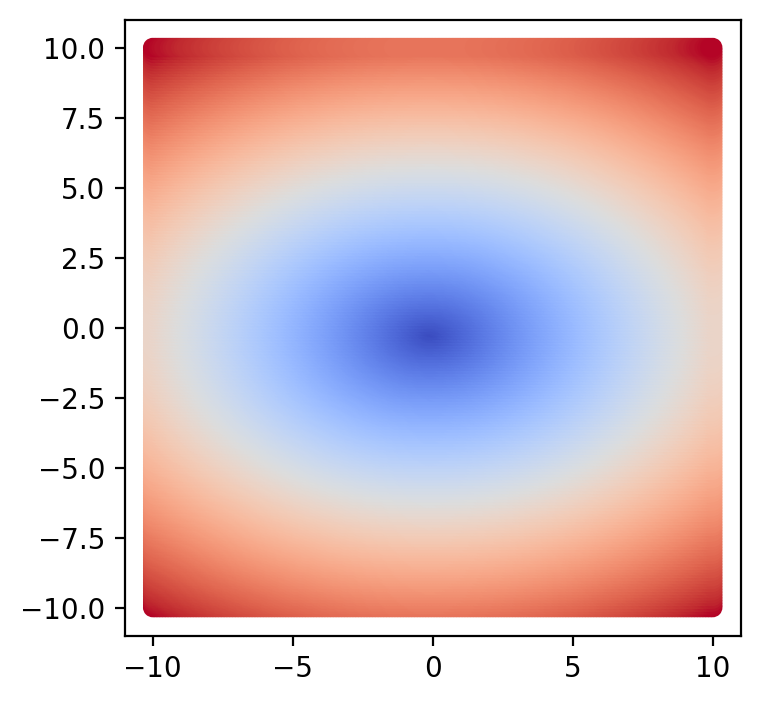

In [75]:
fig = plt.figure(figsize=(4,4))
ax = plt.gca() #you first need to get the axis handle
ax.set_aspect(1) 
cm = plt.cm.get_cmap('coolwarm')
plt.scatter(X1, X2, c=Y, cmap=cm)
plt.show()

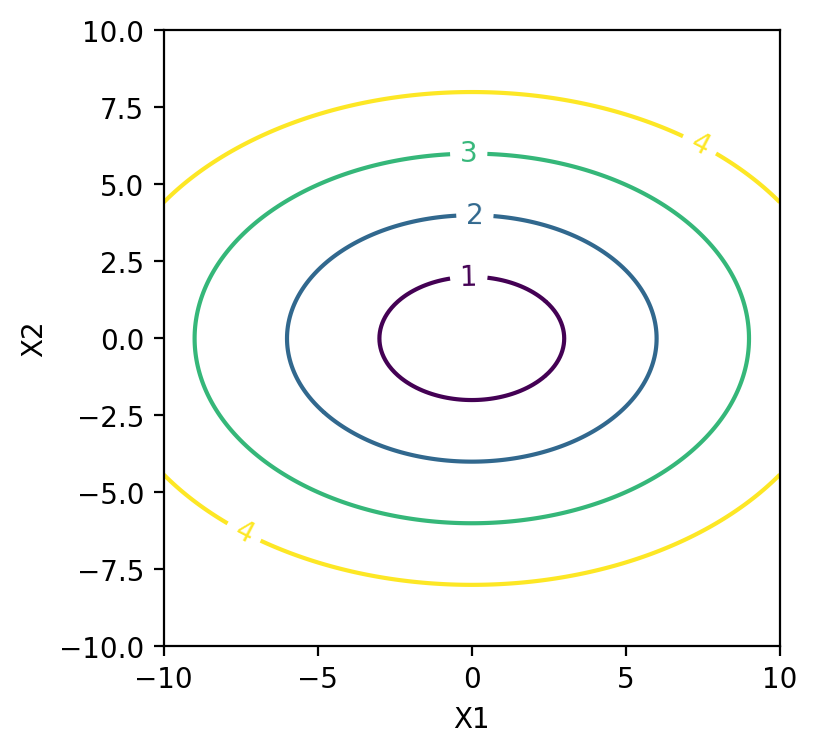

In [76]:
fig = plt.figure(figsize=(4, 4))
ax = plt.gca() #you first need to get the axis handle
ax.set_aspect(1) 
levels = [1,2,3,4]
cp = plt.contour(X1, X2, Y,levels) # here we show some of the level curves
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

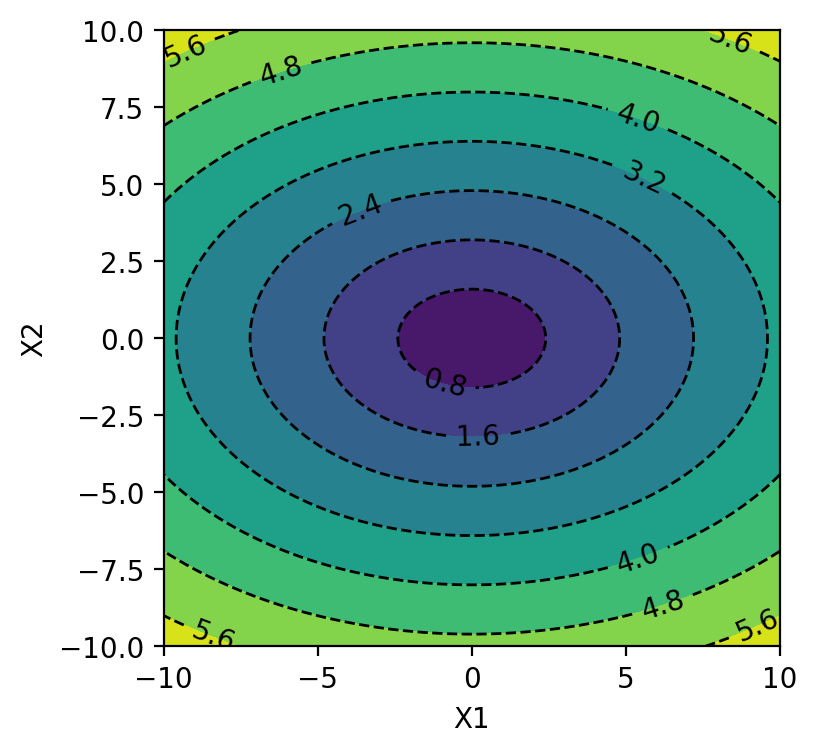

In [77]:
plt.figure(figsize=(4,4))
ax = plt.gca() #you first need to get the axis handle
ax.set_aspect(1) 
cp = plt.contour(X1, X2, Y, colors='black', linestyles='dashed', linewidths=1)
plt.clabel(cp, inline=1, fontsize=10)
cp = plt.contourf(X1, X2, Y, )
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

### 2) Data Application with Gradient Descent

In [78]:
data = pd.read_csv('https://github.com/dvasiliu/AML/blob/main/Data%20Sets/Advertising.csv?raw=true')

Predict $$\text{Sales} = \beta_1*\text{TV} +\beta_2*\text{Radio}$$

We want that the difference between Sales and Predict Sales to be as small as possible -> Minimize the sum of squared errors

BIG IDEA: we start with a random choice of $\beta_1$, and $\beta_2$, and then iteratively update them.

$$L(\beta_1,\beta_2):=\sum_{i=1}^{n}(y_i-\beta_1\cdot x_{i1} -\beta_2\cdot x_{i2})^2$$

$$\frac{\partial{L}}{\partial \beta_1}=\sum_{i=1}^{n} 2\cdot (y_i-\beta_1\cdot x_{i1} -\beta_2\cdot x_{i2})\cdot (-x_{i1})$$

In [79]:
# np.column_stack is very useful to concatenate two(or more) columns from the data frame into a matrix  
y = data['Sales']
x = np.column_stack((data['TV'], data['Radio'])) #, data['Newspaper']))
 
scaler = StandardScaler()
xscaled = scaler.fit_transform(x)
yc = y - np.mean(y)

In [80]:
def obj_grad(w,x,y):
    n = x.shape[0]
    errors = y - x@w
    obj = np.sum(errors**2)/n
    grad = -(2/n)*errors@x
    return obj, grad

In [81]:
# initialize hyper-parameters
w = np.array([1,1]) # a very imprecise guess to initialize the coefficients
lr = .001 # the learning rate
tolerance = 1e-6
 
old_w = []
mse = []

In [82]:
# Perform Gradient Descent
iterations = 1
maxiter = 8000
loss_all = []
for i in range(maxiter):
    loss_temp, gradient = obj_grad(w, xscaled, yc)
    new_w = w - lr * gradient # here we update the coefficients in the direction of the negative gradient
    loss_all.append(loss_temp)
    # Print error every 10 iterations
    if iterations % 100 == 0:
        print("Iteration: %d - Mean Squarred Error: %.4f" % (iterations, loss_temp))
        old_w.append(new_w)
        mse.append(loss_temp)
 
    # Stopping Condition
    if np.sum(abs(new_w - w)) < tolerance:
        print('The Gradient Descent Algorithm has converged')
        break
 
    iterations += 1
    w = new_w
 
print('w =', w)

Iteration: 100 - Mean Squarred Error: 10.8799
Iteration: 200 - Mean Squarred Error: 8.1033
Iteration: 300 - Mean Squarred Error: 6.2794
Iteration: 400 - Mean Squarred Error: 5.0812
Iteration: 500 - Mean Squarred Error: 4.2939
Iteration: 600 - Mean Squarred Error: 3.7767
Iteration: 700 - Mean Squarred Error: 3.4367
Iteration: 800 - Mean Squarred Error: 3.2133
Iteration: 900 - Mean Squarred Error: 3.0665
Iteration: 1000 - Mean Squarred Error: 2.9700
Iteration: 1100 - Mean Squarred Error: 2.9065
Iteration: 1200 - Mean Squarred Error: 2.8648
Iteration: 1300 - Mean Squarred Error: 2.8373
Iteration: 1400 - Mean Squarred Error: 2.8193
Iteration: 1500 - Mean Squarred Error: 2.8074
Iteration: 1600 - Mean Squarred Error: 2.7996
Iteration: 1700 - Mean Squarred Error: 2.7945
Iteration: 1800 - Mean Squarred Error: 2.7911
Iteration: 1900 - Mean Squarred Error: 2.7889
Iteration: 2000 - Mean Squarred Error: 2.7874
Iteration: 2100 - Mean Squarred Error: 2.7864
Iteration: 2200 - Mean Squarred Error: 2.7

#### Visualization

In [83]:
all_ws = np.array(old_w)
mse = []
# Just for visualization
mse.append(10)
mse.append(8)
mse.append(6)
mse.append(4)
mse.append(3)
mse.append(2.8)
 
levels = np.sort(np.array(mse))

In [84]:
w0 = np.linspace(0 , w[0]*2 , 200)
w1 = np.linspace(0 , w[1]*2 , 200)
mse_vals = np.zeros(shape=(w0.size, w1.size))

In [85]:
for i, value1 in enumerate(w0):
    for j, value2 in enumerate(w1):
        w_temp = np.array([value1,value2])        
        mse_vals[i, j] = obj_grad(w_temp, xscaled, yc)[0]

In [86]:
mse_vals

array([[27.08574375, 26.91870692, 26.75323588, ..., 24.40871447,
        24.55013914, 24.69312959],
       [26.76668508, 26.59976903, 26.43441876, ..., 24.11344842,
        24.25499385, 24.39810509],
       [26.45072754, 26.28393226, 26.11870277, ..., 23.82128348,
        23.96294969, 24.1061817 ],
       ...,
       [24.10140266, 23.95815844, 23.81648001, ..., 26.11151744,
        26.27673471, 26.44351778],
       [24.39326456, 24.25014112, 24.10858346, ..., 26.42717195,
        26.59251   , 26.75941384],
       [24.68822759, 24.54522492, 24.40378804, ..., 26.74592759,
        26.91138641, 27.07841103]])

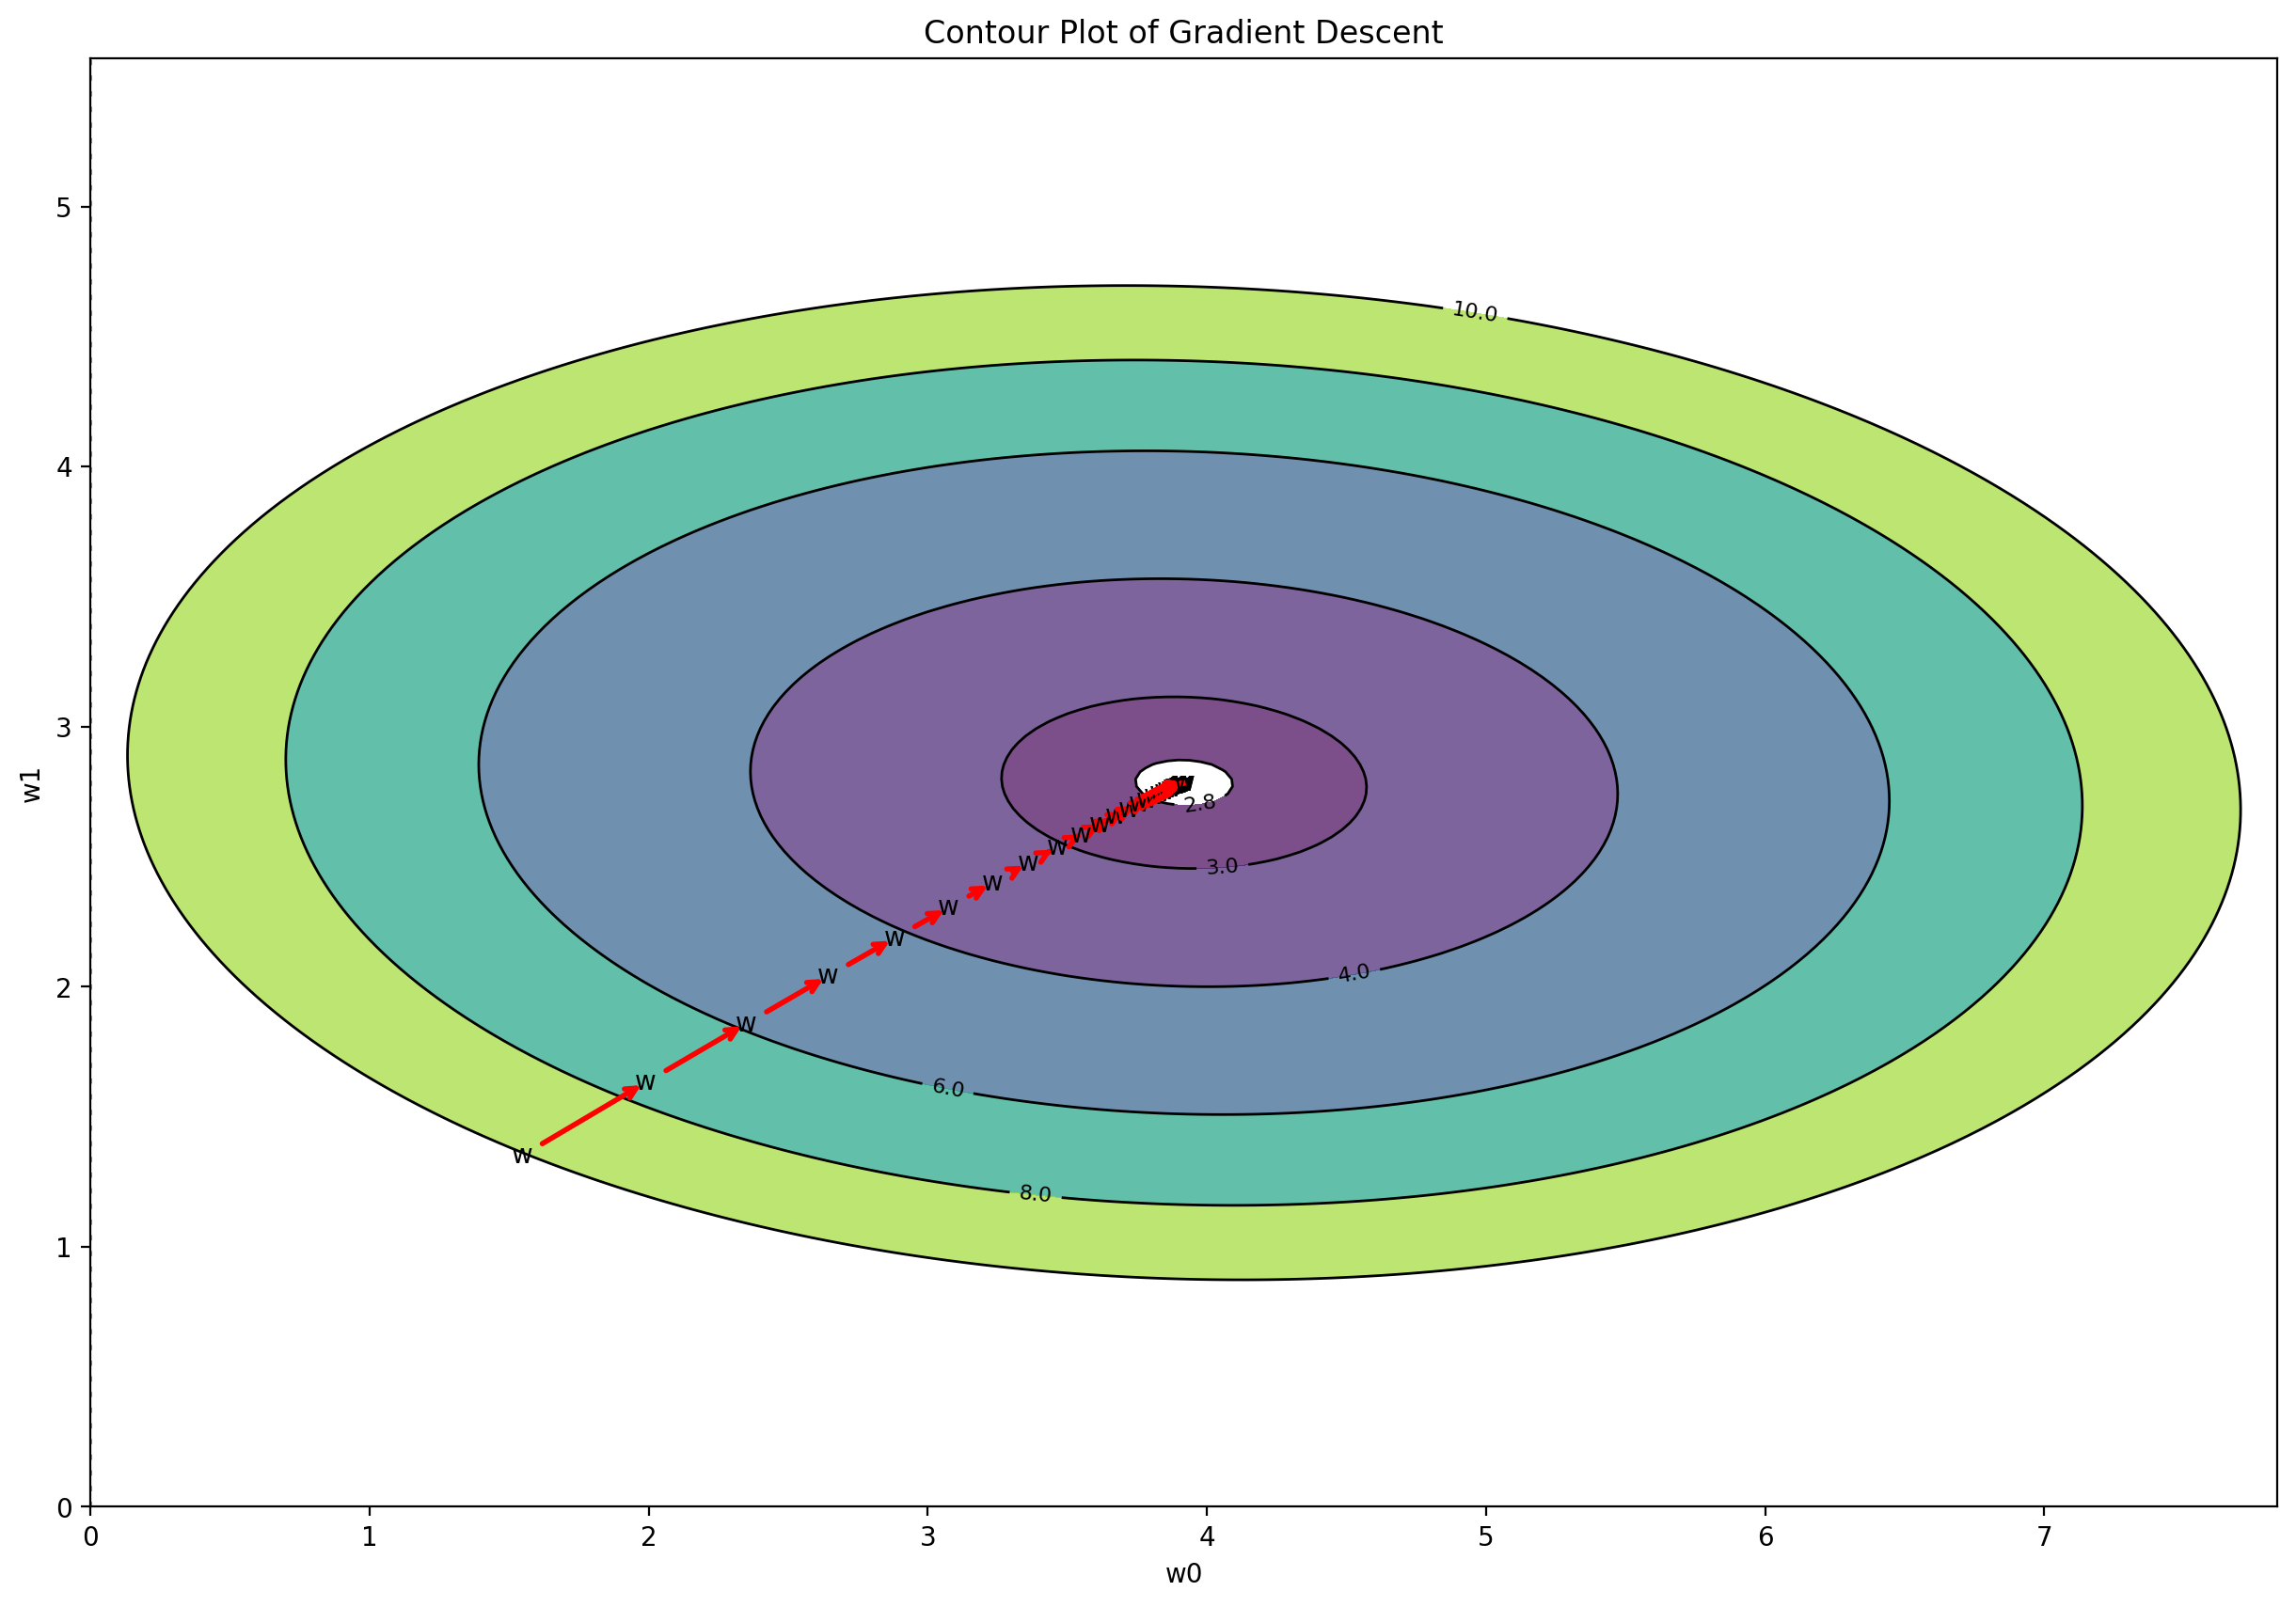

In [87]:
plt.figure(figsize=(15,10))
plt.contourf(w0, w1, mse_vals, levels,alpha=.7)
plt.axhline(0, color='black', alpha=0.5, dashes=[2, 4],linewidth=1)
plt.axvline(0, color='black', alpha=0.5, dashes=[2, 4],linewidth=1)
for i in range(len(old_w) - 1):
    plt.annotate('w', xy=all_ws[i + 1, :], xytext=all_ws[i, :],
                arrowprops={'arrowstyle': '->', 'color': 'r', 'lw': 2},
                va='center', ha='center')
 
CS = plt.contour(w0, w1, mse_vals, levels, linewidths=1,colors='black')
plt.clabel(CS, inline=1, fontsize=8)
plt.title("Contour Plot of Gradient Descent")
plt.xlabel("w0")
plt.ylabel("w1")
plt.show()

## <font color='navy' size=6>  Contour Plots and Gradient Descent Visualizations

In [12]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# <font color='blue'> Gradient Descent Visualization

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

## <font color='blue'> An Example with Contour Plots

In [14]:
# here we generate many equally spaced points
x1 = np.linspace(-10.0, 10.0, 201)
x2 = np.linspace(-10.0, 10.0, 201)

In [15]:
x1

array([-10. ,  -9.9,  -9.8,  -9.7,  -9.6,  -9.5,  -9.4,  -9.3,  -9.2,
        -9.1,  -9. ,  -8.9,  -8.8,  -8.7,  -8.6,  -8.5,  -8.4,  -8.3,
        -8.2,  -8.1,  -8. ,  -7.9,  -7.8,  -7.7,  -7.6,  -7.5,  -7.4,
        -7.3,  -7.2,  -7.1,  -7. ,  -6.9,  -6.8,  -6.7,  -6.6,  -6.5,
        -6.4,  -6.3,  -6.2,  -6.1,  -6. ,  -5.9,  -5.8,  -5.7,  -5.6,
        -5.5,  -5.4,  -5.3,  -5.2,  -5.1,  -5. ,  -4.9,  -4.8,  -4.7,
        -4.6,  -4.5,  -4.4,  -4.3,  -4.2,  -4.1,  -4. ,  -3.9,  -3.8,
        -3.7,  -3.6,  -3.5,  -3.4,  -3.3,  -3.2,  -3.1,  -3. ,  -2.9,
        -2.8,  -2.7,  -2.6,  -2.5,  -2.4,  -2.3,  -2.2,  -2.1,  -2. ,
        -1.9,  -1.8,  -1.7,  -1.6,  -1.5,  -1.4,  -1.3,  -1.2,  -1.1,
        -1. ,  -0.9,  -0.8,  -0.7,  -0.6,  -0.5,  -0.4,  -0.3,  -0.2,
        -0.1,   0. ,   0.1,   0.2,   0.3,   0.4,   0.5,   0.6,   0.7,
         0.8,   0.9,   1. ,   1.1,   1.2,   1.3,   1.4,   1.5,   1.6,
         1.7,   1.8,   1.9,   2. ,   2.1,   2.2,   2.3,   2.4,   2.5,
         2.6,   2.7,

In [16]:
# here we make an objective function
X1, X2 = np.meshgrid(x1, x2)
Y = np.sqrt(X1**2/9 + X2**2/4)

Here we have the function:

$$F(x_1,x_2):=\sqrt{\frac{x_1^2}{9}+\frac{x_2^2}{4}}$$

What shape is implied by the equation

$$\frac{x_1^2}{9}+\frac{x_2^2}{4}=k$$

Here the function is $$f(x_1,x_2):=\frac{(x_1)^2}{9}+\frac{(x_2)^2}{4}$$

The level curve is the geometric locus of points $(x_1,x_2)$ such that

$$f(x_1,x_2)=l$$


The gradient of $f$ is labeled by $\nabla(f)$ and is the vector of partial derivatives with respect to $x1$ and $x2$

$$\nabla(f):=\left(\frac{\partial{f}}{\partial{x1}},\frac{\partial{f}}{\partial{x2}}\right)=\left(\frac{2x1}{9},\frac{x2}{2}\right)$$

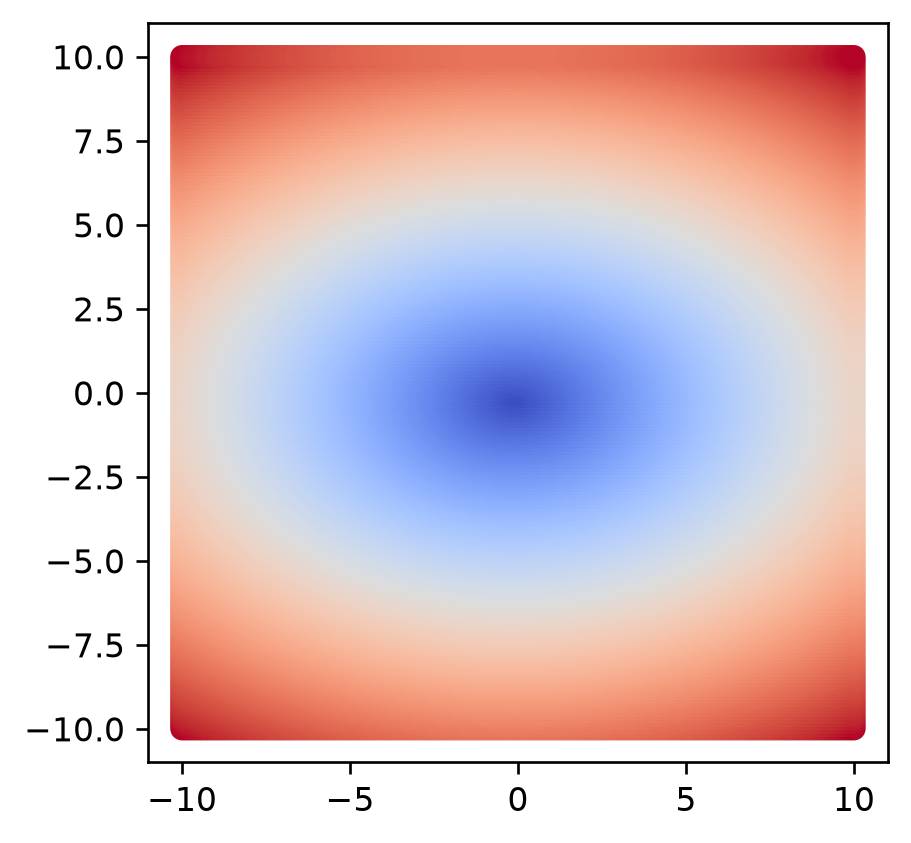

In [17]:
fig = plt.figure(figsize=(4,4))
ax = plt.gca() #you first need to get the axis handle
ax.set_aspect(1)
cm = mpl.colormaps['coolwarm']
plt.scatter(X1, X2, c=Y, cmap=cm)
plt.show()

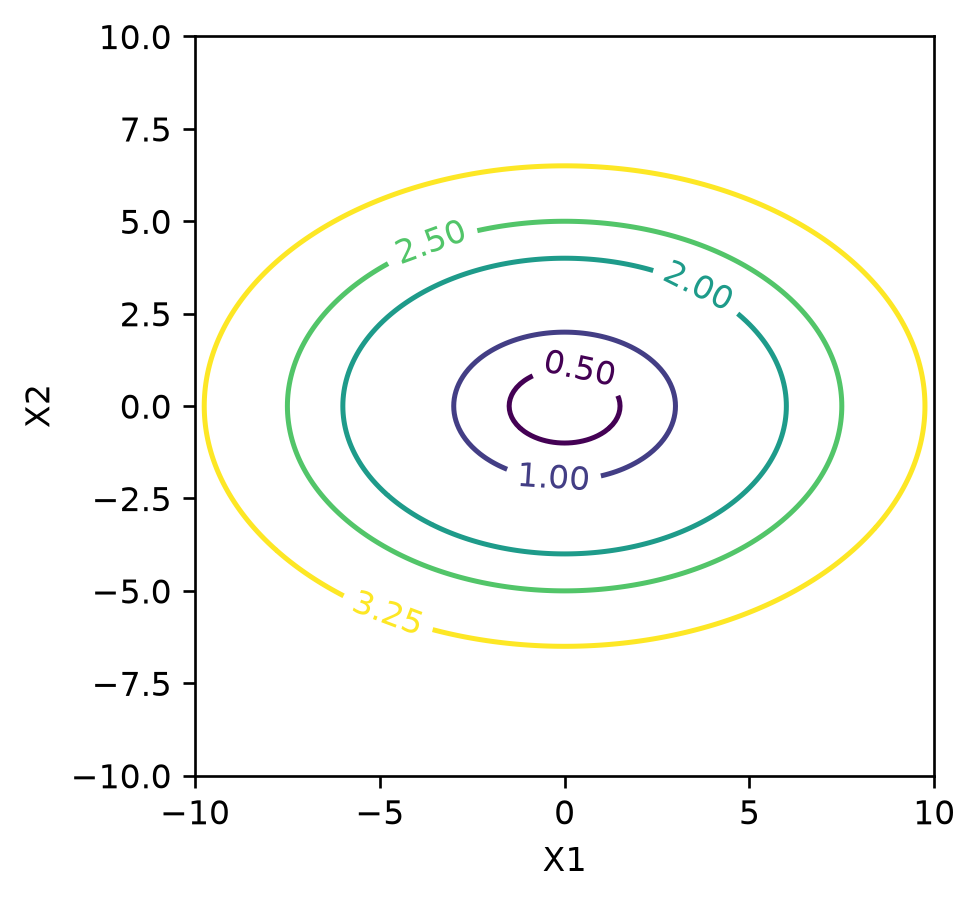

In [18]:
fig = plt.figure(figsize=(4, 4))
ax = plt.gca() #you first need to get the axis handle
ax.set_aspect(1)
levels = [0.5,1,2,2.5,3.25]
cp = plt.contour(X1, X2, Y,levels) # here we show some of the level curves
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

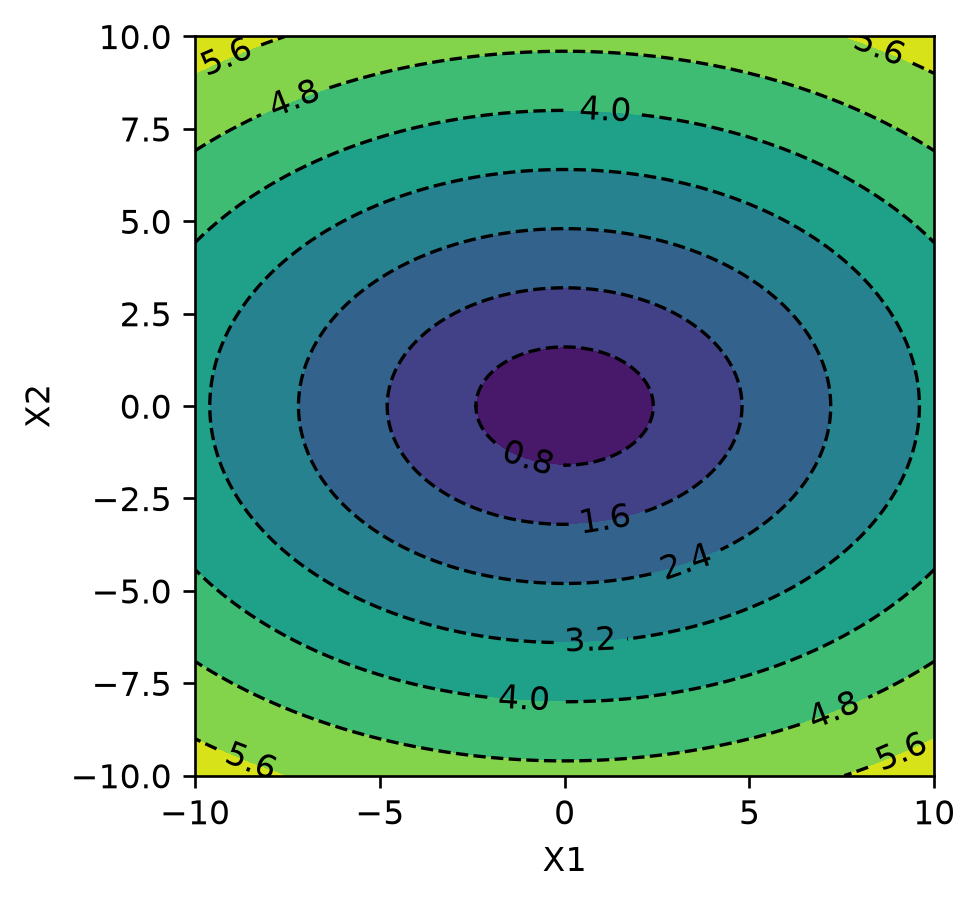

In [19]:
plt.figure(figsize=(4,4))
ax = plt.gca() #you first need to get the axis handle
ax.set_aspect(1)
cp = plt.contour(X1, X2, Y, colors='black', linestyles='dashed', linewidths=1)
plt.clabel(cp, inline=1, fontsize=10)
cp = plt.contourf(X1, X2, Y, )
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## <font color='blue'> Data Application with Gradient Descent

In [20]:
data = pd.read_csv('https://github.com/yanhai-xiong/DATA301-AML/blob/main/Data%20Sets/Advertising.csv?raw=true')

In [21]:
data

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


## Machine Learning -> Linear Case

Predict Sales = c1 * TV + c2 * Radio + c3 * Newspaper

We want that the difference between Sales and Predict Sales to be as small as possible -> Minimize the sum of squared errors

BIG IDEA: we start with a random choice of c1, c2 and c3 and then iteratively update them.

In [23]:
# np.column_stack is very useful to concatenate two(or more) columns from the data frame into a matrix
y = data['Sales']
x = np.column_stack((data['TV'], data['Radio'], data['Newspaper']))

scaler = StandardScaler()
x = scaler.fit_transform(x)

$$L(\beta_1,\beta_2):=\sum_{i=1}^{n}(y_i-\beta_1\cdot x_{i1} -\beta_2\cdot x_{i2})^2$$

$$\frac{\partial{L}}{\partial \beta_1}=\sum_{i=1}^{n} 2\cdot (y_i-\beta_1\cdot x_{i1} -\beta_2\cdot x_{i2})\cdot (-x_{i1})$$

## No Intercept Term

We make sure we scale x by the z-scores and then we subtract the mean of $y$,i.e. $\bar{y}$, from the y values.

In [24]:
np.mean(y)

np.float64(14.0225)

In [25]:
#
y = y - np.mean(y)

In [26]:
np.mean(y) # essentially a zero mean

np.float64(-8.526512829121202e-16)

In [29]:
# here we can guess some weights (aka coefficients)
w = [10,20,30]

In [30]:
x.dot(w) # this is the correct matrix - vector product

array([ 82.69733612,  29.76975678,  68.91417578,  63.46974734,
        25.56360529,  79.84449492,  -7.31892715, -34.25710221,
       -85.5598605 , -34.66315578, -41.81077014, -27.77563301,
        50.40451571, -59.1896073 ,  41.00589678,  69.50556767,
       123.99195567,  72.61363348, -29.74449121, -14.92848413,
        45.87230263, -23.72027663,   0.7281627 ,  -5.11873537,
       -41.21891829, -28.42724438, -17.12592589,  -8.56810759,
         6.4926813 ,  -4.58666119,  41.29612426,  -0.79478195,
       -35.9767518 , -32.34351841, -67.49652169, -39.56128815,
         6.4399814 ,  47.76450565,  -1.21920077,  30.94557063,
         6.6183285 ,  28.43573136, -16.60393277, -18.82040156,
         6.65231619,   3.55086282, -17.63711938,  18.82402515,
        25.99592009, -16.34954947, -15.48313112, -61.1214713 ,
        45.48819113,  73.99475608,   0.74488749,  82.01483573,
         5.19114948, -26.02421824,  52.87919513, -13.49605813,
       -52.28051964,  72.93399196,  -4.20588867, -27.21

In [31]:
errors = y - x.dot(w)

## An Equivalent Approach

In [32]:
# augment x with a columns of 1's
x = np.column_stack([np.ones(len(x)),x])

In [33]:
pd.DataFrame(data=x)

,0,1,2,3
0,1.0,0.969852,0.981522,1.778945
1,1.0,-1.197376,1.082808,0.669579
2,1.0,-1.516155,1.528463,1.783549
3,1.0,0.052050,1.217855,1.286405
4,1.0,0.394182,-0.841614,1.281802
...,...,...,...,...
195,1.0,-1.270941,-1.321031,-0.771217
196,1.0,-0.617035,-1.240003,-1.033598
197,1.0,0.349810,-0.942899,-1.111852
198,1.0,1.594565,1.265121,1.640850


## Matrix-Vector product

$$\text{x.dot(w)}\overset{\Delta}{=}w_1\cdot \text{col}_1(x)+w_2\cdot \text{col}_2(x)+...w_p\cdot\text{col}_p(x)$$

## Linear Model with Intercept Term

$$\text{Linear Model w/ Intercept}\overset{\Delta}{=}w_0\cdot 1+w_1\cdot \text{col}_1(x)+w_2\cdot \text{col}_2(x)+...w_p\cdot\text{col}_p(x)$$

In [34]:
# here I would like to do a weighted mean or just a linear combination of the columns of x
# w1*x1 +w2*x2
# we can initialize the vector of the weights randomly
w = np.random.uniform(size=4)
x.dot(w) # we just made a linear combination of the columns in x by using the coefficients in w

array([ 2.74777691,  0.14594728,  0.92649046,  1.74610684,  0.80121699,
        1.14807279, -0.69042645, -0.97991146, -3.16446976, -0.55193765,
       -1.67654283, -0.09323635,  0.44405946, -1.83999066,  1.529741  ,
        2.26736834,  2.51773474,  2.90294023, -1.24082795, -0.28682723,
        1.70450412,  0.00479696, -0.97374838,  0.4797161 , -1.63127262,
        0.06739136, -0.32400707,  0.48338641,  0.99351026, -0.67595848,
        2.1499107 , -0.26300774, -1.3474803 ,  0.1386231 , -2.10333194,
        0.01438817,  1.2709911 ,  0.88090663, -0.70557806,  1.5099863 ,
        0.61395866,  1.03800479,  0.783251  , -0.07521983, -0.66095399,
        0.34168718, -0.89660084,  1.34456831,  1.19641667, -1.01829114,
       -0.09488515, -1.84681844,  1.80273227,  2.26606644,  0.97494307,
        2.60318662, -0.80550106, -0.67135017,  2.00482069,  0.26229605,
       -2.04948481,  2.78961812,  0.57000072, -0.85531664,  0.63588222,
       -2.26458562, -1.98047911, -1.03936709,  0.50657678,  1.49

In [35]:
# we can inspect the dimensionality of y
y.shape

(200,)

## Implementation of the Gradient Function and the Loss

In [ ]:
# this is the calculation of the gradient for the Ridge Objective function
def gradient_ridge(beta,x,y): # we defined a function that computes the gradient of the objective function
    n = len(y) # the number of observations
    y_hat = x.dot(beta).flatten() # we create the linear combination of the features in x by using the weights in beta
    error = (y - y_hat) # calculation of residuals
    ridge_objective = (1.0 /n) * np.sum(error**2) + alpha*np.sum(beta**2)
    gradient = -(2.0 /n) * error.dot(x) + alpha*2*beta # the calculation is straight forward
    return gradient, ridge_objective

## RIDGE Regression

The objective function is

$$\text{Loss}:=\text{MSE} + \alpha\cdot \sum_{j=1}^{p}\beta_j^2$$

and its gradient is:

$$\frac{\partial}{\partial{\beta_j}}\text{Loss}=\frac{\partial}{\partial{\beta_j}}\text{MSE} + 2\cdot\alpha\cdot \beta_j$$


In [ ]:
# this is the calculation of the gradient for the MSE
def gradient_mse(beta,x,y): # we defined a function that computes the gradient of the objective function
    n = len(y) # the number of observations
    y_hat = x.dot(beta).flatten() # we create the linear combination of the features in x by using the weights in beta
    error = (y - y_hat) # calculation of residuals
    mse = (1.0 /n) * np.sum(error**2)
    gradient = -(2.0 /n) * error.dot(x)  # the calculation is straight forward
    return gradient, mse

In [ ]:
w = [10,20,30,40]

In [ ]:
# let's test the function
grad, loss = gradient_mse(w,x,y)

In [ ]:
grad

array([17.44920684, 56.34461674, 72.92079019])

In [ ]:
loss

1831.8876671258863

In [ ]:
lr = 0.02
new_w = w - lr*grad

In [ ]:
new_w

array([ 9.65101586, 18.87310767, 28.5415842 ])

In [ ]:
gradient_mse(new_w,x,y) # there is progress

(array([16.46247932, 53.01971635, 69.16634655]), 1660.7383696663244)

In [ ]:
# let's do an experiment
# let's update w in the direction of grad -> we have to decide on a learning rate
# i.e. how much we  travel in the direction of the gradient
lr = 0.01
new_w = w - lr*grad

In [ ]:
new_w

array([2.0381316 , 2.99778547])

In [ ]:
# let's check the loss at the new set of weights
new_grad, new_loss = gradient_mse(new_w,x,y)

In [ ]:
new_loss

6.32163580736815

In [ ]:
alpha=0.01
w = np.random.uniform(size=4) # a very imprecise guess to initialize the coefficients
lr = .01 # the learning rate
tolerance = 1e-6

old_w = []
mse = []

In [ ]:
w

array([11.30999012, 16.3104529 , 10.59457363])

In [ ]:
# Perform Gradient Descent
iterations = 1
maxiter = 10000
loss_all = []
for i in range(maxiter):
    gradient, loss_temp = gradient_ridge(w, x, y)
    new_w = w - lr * gradient # here we update the coefficients in the direction of the negative gradient
    loss_all.append(loss_temp)
    # Print error every 10 iterations
    if iterations % 100 == 0:
        print("Iteration: %d - Mean Squarred Error: %.4f" % (iterations, loss_temp))
        old_w.append(new_w)
        mse.append(loss_temp)

    # Stopping Condition
    if np.sum(abs(new_w - w)) < tolerance:
        print('The Gradient Descent Algorithm has converged')
        break

    iterations += 1
    w = new_w

print('w =', w)

Iteration: 100 - Mean Squarred Error: 8.3968
Iteration: 200 - Mean Squarred Error: 5.0315
Iteration: 300 - Mean Squarred Error: 4.9624
Iteration: 400 - Mean Squarred Error: 4.9603
Iteration: 500 - Mean Squarred Error: 4.9602
Iteration: 600 - Mean Squarred Error: 4.9602
Iteration: 700 - Mean Squarred Error: 4.9602
Iteration: 800 - Mean Squarred Error: 4.9602
The Gradient Descent Algorithm has converged
w = [ 1.38836625e+01  3.88135890e+00  2.76191320e+00 -9.59561269e-03]


In [ ]:
mse_all[-1]

4.960200883633443

In [ ]:
all_ws = np.array(old_w)
mse = []
# Just for visualization
mse.append(20)
mse.append(10)
mse.append(5)
mse.append(4)
mse.append(3)

levels = np.sort(np.array(mse))

In [ ]:
w0 = np.linspace(-w[0] * 6, w[0] * 6, 100)
w1 = np.linspace(-w[1] * 6, w[1] * 6, 100)
mse_vals = np.zeros(shape=(w0.size, w1.size))

In [ ]:
for i, value1 in enumerate(w0):
    for j, value2 in enumerate(w1):
        w_temp = np.array((value1,value2))
        mse_vals[i, j] = gradient_mse(w_temp, x_scaled, y)[1]


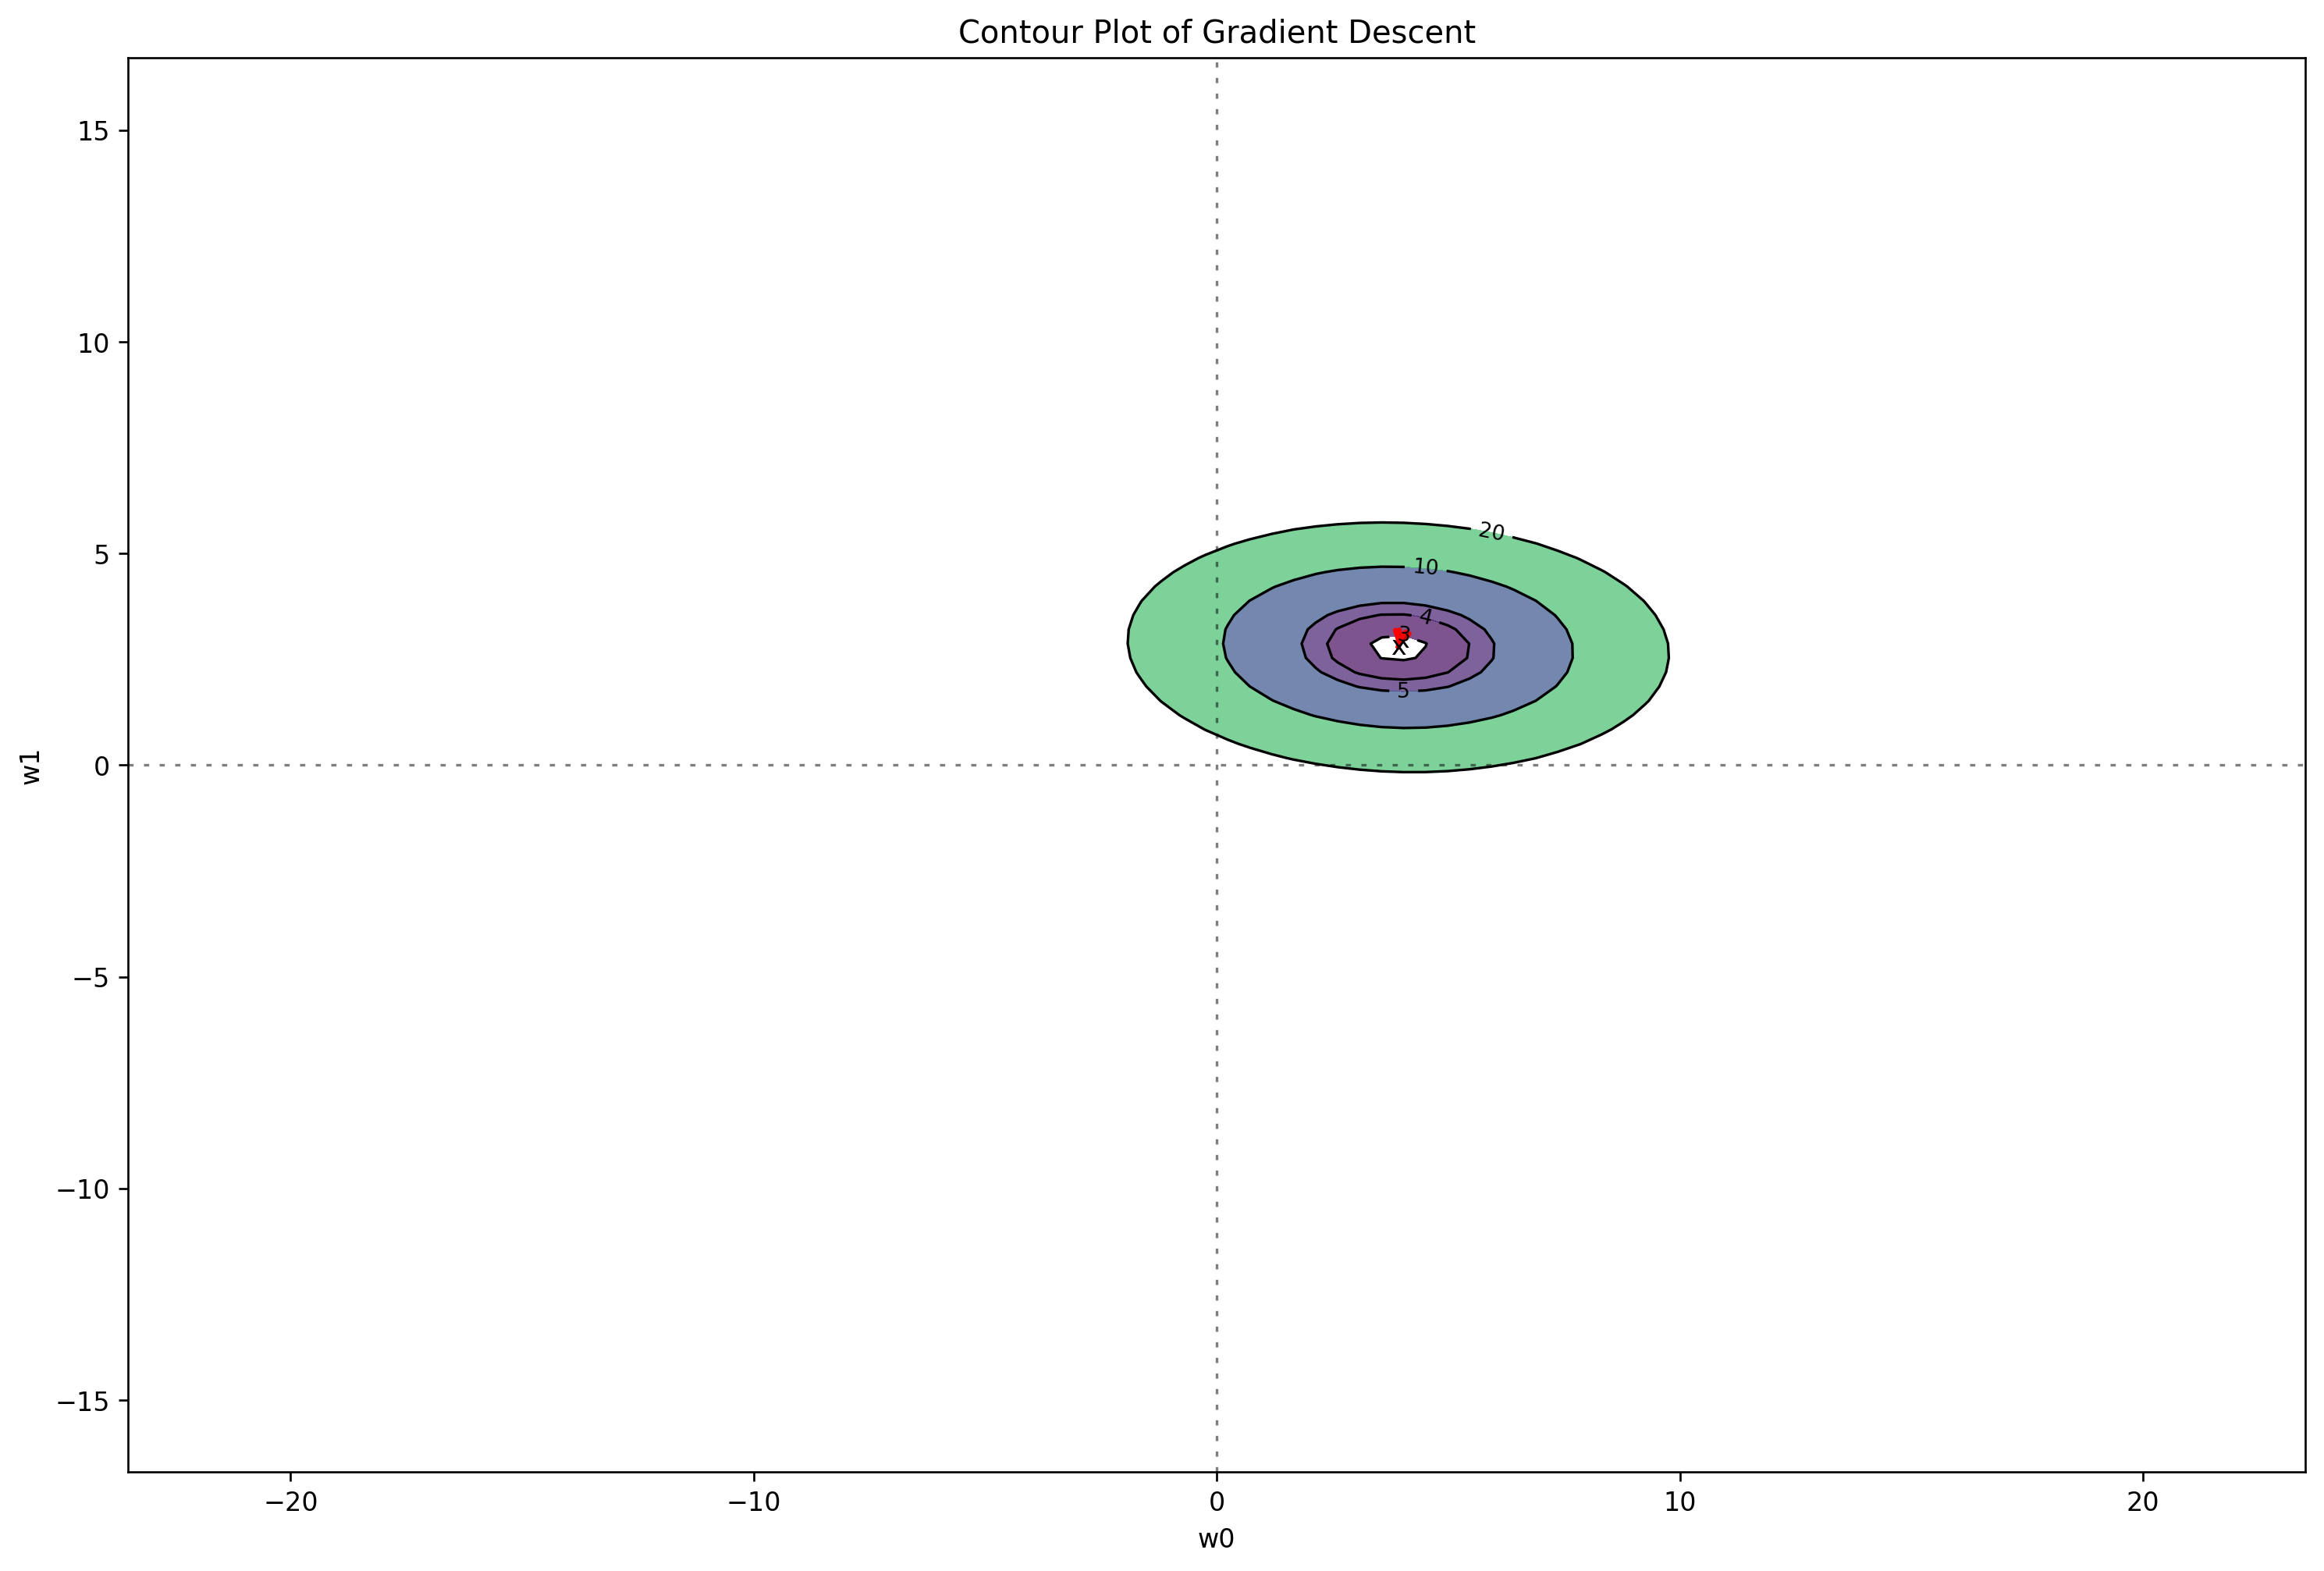

In [ ]:
plt.figure(figsize=(15,10))
plt.contourf(w0, w1, mse_vals, levels,alpha=.7)
plt.axhline(0, color='black', alpha=0.5, dashes=[2, 4],linewidth=1)
plt.axvline(0, color='black', alpha=0.5, dashes=[2, 4],linewidth=1)
for i in range(len(old_w) - 1):
    plt.annotate('x', xy=all_ws[i + 1, :], xytext=all_ws[i, :],
                 arrowprops={'arrowstyle': '->', 'color': 'r', 'lw': 2},
                 va='center', ha='center')

CS = plt.contour(w0, w1, mse_vals, levels, linewidths=1,colors='black')
plt.clabel(CS, inline=1, fontsize=8)
plt.title("Contour Plot of Gradient Descent")
plt.xlabel("w0")
plt.ylabel("w1")
plt.show()